In [54]:
import torch
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, random_split

import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import numpy as np

from PIL import Image
import os

In [55]:
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

PyTorch version: 2.11.0+cpu
Torchvision version: 0.26.0+cpu


In [56]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cpu


In [57]:
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [58]:
train_dataset_full = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Full training dataset:", len(train_dataset_full))
print("Test dataset:", len(test_dataset))

Full training dataset: 60000
Test dataset: 10000


In [59]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print(classes)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [60]:
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

train_dataset, val_dataset = random_split(
    train_dataset_full,
    [train_size, val_size]
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

Training images: 48000
Validation images: 12000
Test images: 10000


In [61]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("DataLoaders ready")

DataLoaders ready


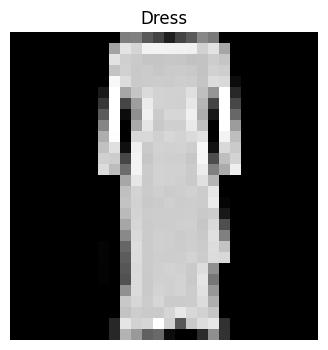

In [62]:
image, label = train_dataset[0]

plt.figure(figsize=(4, 4))

plt.imshow(
    image.squeeze(),
    cmap="gray"
)

plt.title(classes[label])
plt.axis("off")

plt.show()

In [63]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.fc1 = nn.Linear(
            64 * 7 * 7,
            128
        )

        self.fc2 = nn.Linear(
            128,
            10
        )

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.relu(self.conv1(x))
        x = self.pool(x)

        x = self.relu(self.conv2(x))
        x = self.pool(x)

        x = x.view(
            x.size(0),
            -1
        )

        x = self.relu(self.fc1(x))

        x = self.fc2(x)

        return x

In [64]:
model = CNN().to(device)

print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


In [65]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [66]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [67]:
num_epochs = 10

for epoch in range(num_epochs):

    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()

    train_loss = (
        running_train_loss /
        len(train_loader)
    )

    train_accuracy = (
        100 *
        train_correct /
        train_total
    )

    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_val_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()

    val_loss = (
        running_val_loss /
        len(val_loader)
    )

    val_accuracy = (
        100 *
        val_correct /
        val_total
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch [1/10] Train Loss: 0.4640 Train Acc: 83.25% Val Loss: 0.3257 Val Acc: 88.28%
Epoch [2/10] Train Loss: 0.2955 Train Acc: 89.19% Val Loss: 0.2575 Val Acc: 90.71%
Epoch [3/10] Train Loss: 0.2472 Train Acc: 90.85% Val Loss: 0.2469 Val Acc: 90.93%
Epoch [4/10] Train Loss: 0.2155 Train Acc: 91.94% Val Loss: 0.2465 Val Acc: 91.40%
Epoch [5/10] Train Loss: 0.1895 Train Acc: 93.04% Val Loss: 0.2177 Val Acc: 92.09%
Epoch [6/10] Train Loss: 0.1655 Train Acc: 93.90% Val Loss: 0.2120 Val Acc: 92.72%
Epoch [7/10] Train Loss: 0.1443 Train Acc: 94.66% Val Loss: 0.2353 Val Acc: 91.99%
Epoch [8/10] Train Loss: 0.1239 Train Acc: 95.38% Val Loss: 0.2392 Val Acc: 92.42%
Epoch [9/10] Train Loss: 0.1041 Train Acc: 96.15% Val Loss: 0.2501 Val Acc: 91.67%
Epoch [10/10] Train Loss: 0.0919 Train Acc: 96.61% Val Loss: 0.2498 Val Acc: 92.47%


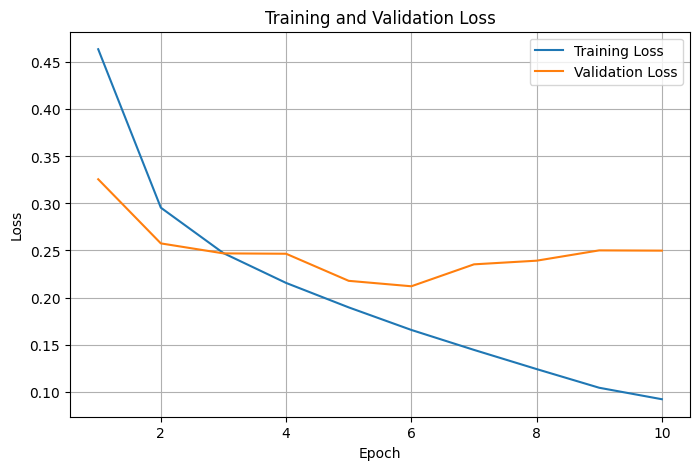

In [68]:
epochs = range(
    1,
    num_epochs + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss"
)

plt.legend()
plt.grid()

plt.show()

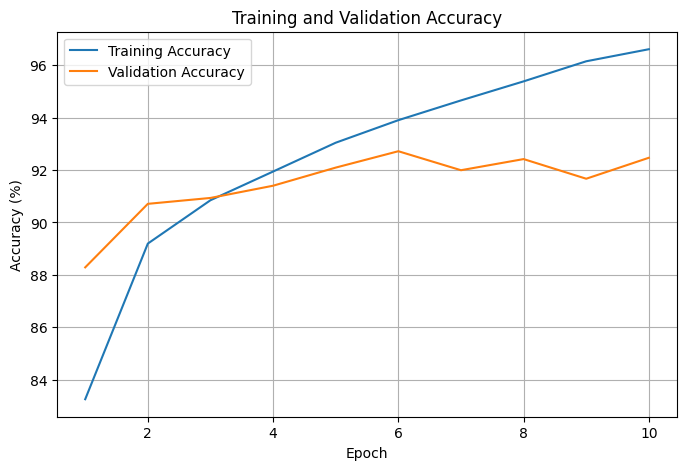

In [69]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "Training and Validation Accuracy"
)

plt.legend()
plt.grid()

plt.show()

In [70]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

test_accuracy = (
    100 * correct / total
)

print(
    f"Test Accuracy: {test_accuracy:.2f}%"
)

Test Accuracy: 91.62%


In [71]:
from sklearn.metrics import confusion_matrix

In [72]:
all_labels = []
all_predictions = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        all_labels.extend(
            labels.numpy()
        )

        all_predictions.extend(
            predicted.cpu().numpy()
        )

In [73]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

[[865   0  20  17   4   1  87   0   6   0]
 [  0 988   1   9   1   0   1   0   0   0]
 [ 19   1 911   7  26   0  36   0   0   0]
 [ 18   3   8 934  17   1  18   0   1   0]
 [  0   0  72  25 849   0  53   0   1   0]
 [  0   0   0   0   0 977   0  19   1   3]
 [110   2  71  29  57   0 723   0   8   0]
 [  0   0   0   0   0   7   0 969   0  24]
 [  5   1   1   6   0   1   2   1 983   0]
 [  0   0   0   0   0   6   1  30   0 963]]


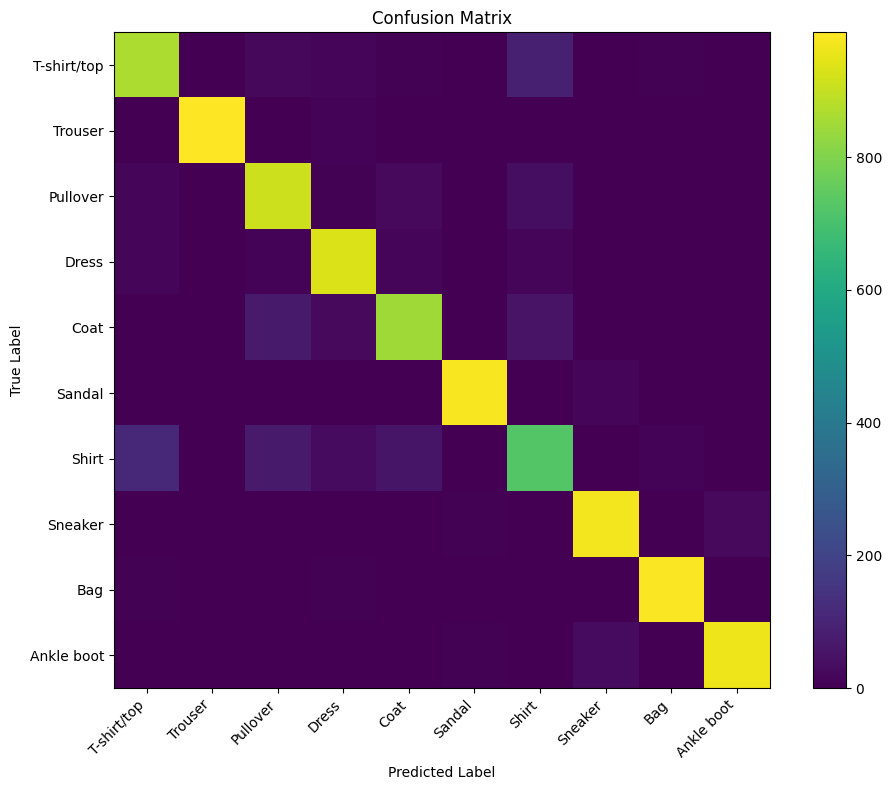

In [74]:
plt.figure(figsize=(10, 8))

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(
    range(10),
    classes,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(10),
    classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.show()

In [75]:
os.makedirs(
    "CNN-Image-Classification/model",
    exist_ok=True
)

print("Model folder ready")

Model folder ready


In [76]:
model_path = (
    "CNN-Image-Classification/"
    "model/220150.pth"
)

torch.save(
    model.state_dict(),
    model_path
)

print("Model saved successfully!")
print(model_path)

Model saved successfully!
CNN-Image-Classification/model/220150.pth


In [77]:
print(
    os.listdir(
        "CNN-Image-Classification/model"
    )
)

['220150.pth', 'model.pth']


In [78]:
custom_transform = transforms.Compose([
    transforms.Grayscale(
        num_output_channels=1
    ),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,),
        (0.5,)
    )
])

In [79]:
import os

custom_dir = "CNN-Image-Classification/custom_images"

os.makedirs(custom_dir, exist_ok=True)

print("Custom image folder:")
print(custom_dir)

print("\nFiles:")
print(os.listdir(custom_dir))

Custom image folder:
CNN-Image-Classification/custom_images

Files:
['sandal.jpeg', '.gitkeep', 'bag2.jpeg', 'sneaker.jpeg', 'tshirt2.jpeg', 'sandal2.jpeg', 'trouser2.jpeg', 'tshirt.jpeg', 'trouser.jpeg', 'bag.jpg', 'sneaker2.jpeg']


In [80]:
image_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp"
)

image_files = [
    file
    for file in os.listdir(custom_dir)
    if file.lower().endswith(image_extensions)
]

print("Number of custom images:", len(image_files))
print("Images:", image_files)

Number of custom images: 10
Images: ['sandal.jpeg', 'bag2.jpeg', 'sneaker.jpeg', 'tshirt2.jpeg', 'sandal2.jpeg', 'trouser2.jpeg', 'tshirt.jpeg', 'trouser.jpeg', 'bag.jpg', 'sneaker2.jpeg']


In [81]:
model_path = "CNN-Image-Classification/model/220150.pth"

loaded_model = CNN().to(device)

loaded_model.load_state_dict(
    torch.load(
        model_path,
        map_location=device
    )
)

loaded_model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [82]:
def predict_custom_image(image_path):

    image = Image.open(image_path)

    image_tensor = custom_transform(
        image
    )

    image_tensor = image_tensor.unsqueeze(0)

    image_tensor = image_tensor.to(device)

    with torch.no_grad():

        output = loaded_model(
            image_tensor
        )

        probabilities = torch.softmax(
            output,
            dim=1
        )

        predicted_class = torch.argmax(
            probabilities,
            dim=1
        ).item()

        confidence = probabilities[
            0,
            predicted_class
        ].item() * 100

    return (
        classes[predicted_class],
        confidence
    )

In [83]:
if len(image_files) == 0:

    print(
        "No custom images found."
    )

else:

    for filename in image_files:

        image_path = os.path.join(
            custom_dir,
            filename
        )

        predicted_class, confidence = (
            predict_custom_image(
                image_path
            )
        )

        print(
            f"Image: {filename}"
        )

        print(
            f"Prediction: {predicted_class}"
        )

        print(
            f"Confidence: {confidence:.2f}%"
        )

        print("-" * 40)

Image: sandal.jpeg
Prediction: Bag
Confidence: 99.76%
----------------------------------------
Image: bag2.jpeg
Prediction: Bag
Confidence: 100.00%
----------------------------------------
Image: sneaker.jpeg
Prediction: Bag
Confidence: 99.84%
----------------------------------------
Image: tshirt2.jpeg
Prediction: Bag
Confidence: 78.69%
----------------------------------------
Image: sandal2.jpeg
Prediction: Bag
Confidence: 98.80%
----------------------------------------
Image: trouser2.jpeg
Prediction: Bag
Confidence: 100.00%
----------------------------------------
Image: tshirt.jpeg
Prediction: Bag
Confidence: 90.07%
----------------------------------------
Image: trouser.jpeg
Prediction: Bag
Confidence: 67.20%
----------------------------------------
Image: bag.jpg
Prediction: Bag
Confidence: 99.82%
----------------------------------------
Image: sneaker2.jpeg
Prediction: Bag
Confidence: 99.98%
----------------------------------------


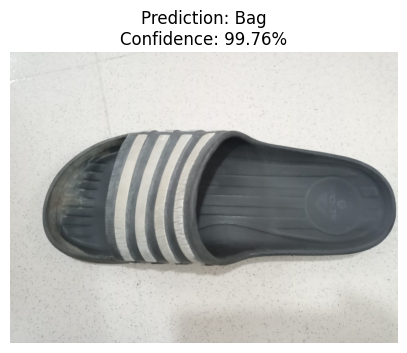

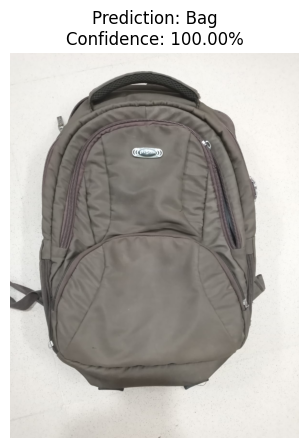

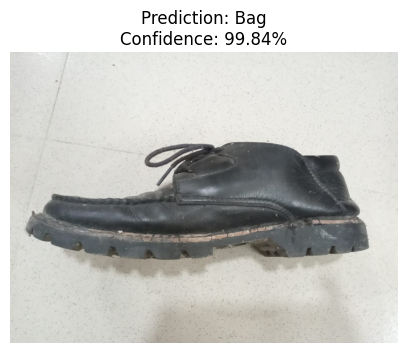

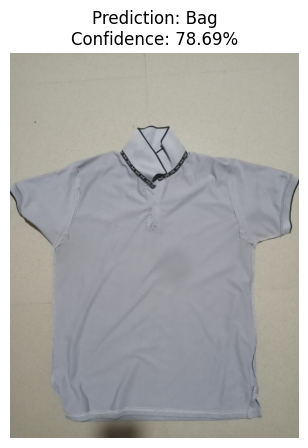

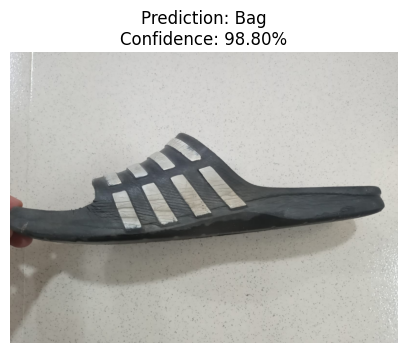

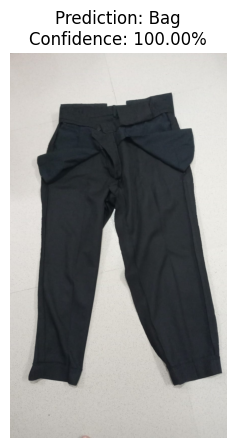

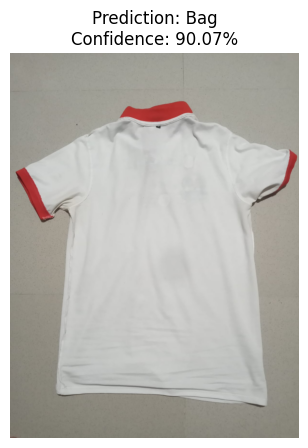

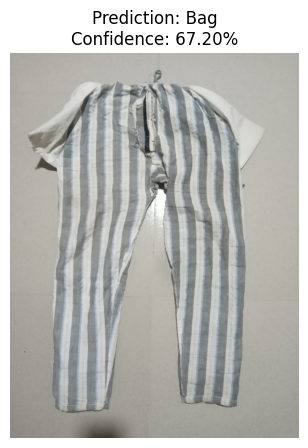

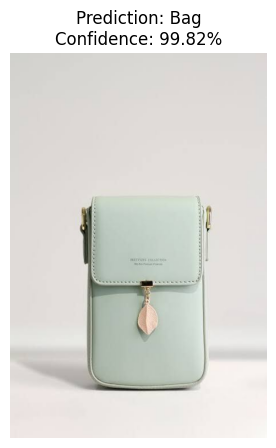

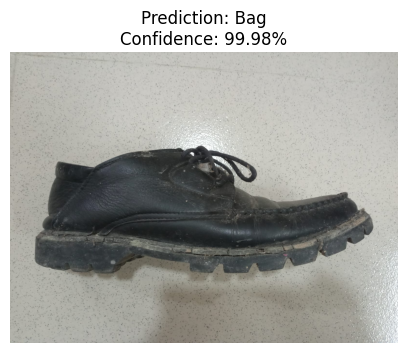

In [84]:
if len(image_files) == 0:

    print(
        "No custom images found."
    )

else:

    for filename in image_files:

        image_path = os.path.join(
            custom_dir,
            filename
        )

        predicted_class, confidence = (
            predict_custom_image(
                image_path
            )
        )

        image = Image.open(
            image_path
        )

        plt.figure(figsize=(5, 5))

        plt.imshow(image)

        plt.title(
            f"Prediction: {predicted_class}\n"
            f"Confidence: {confidence:.2f}%"
        )

        plt.axis("off")

        plt.show()

In [85]:
image, true_label = test_dataset[0]

image_input = image.unsqueeze(0).to(device)

loaded_model.eval()

with torch.no_grad():

    output = loaded_model(
        image_input
    )

    predicted_label = torch.argmax(
        output,
        dim=1
    ).item()

print(
    "True Label:",
    classes[true_label]
)

print(
    "Predicted Label:",
    classes[predicted_label]
)

True Label: Ankle boot
Predicted Label: Ankle boot


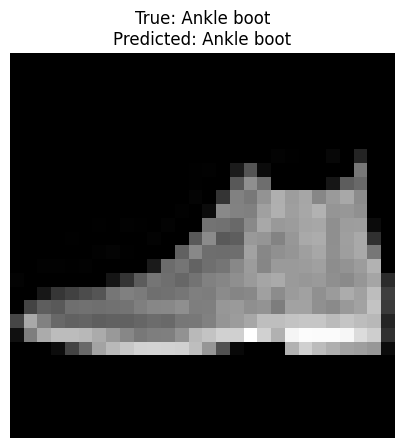

In [86]:
plt.figure(figsize=(5, 5))

plt.imshow(
    image.squeeze(),
    cmap="gray"
)

plt.title(
    f"True: {classes[true_label]}\n"
    f"Predicted: {classes[predicted_label]}"
)

plt.axis("off")

plt.show()

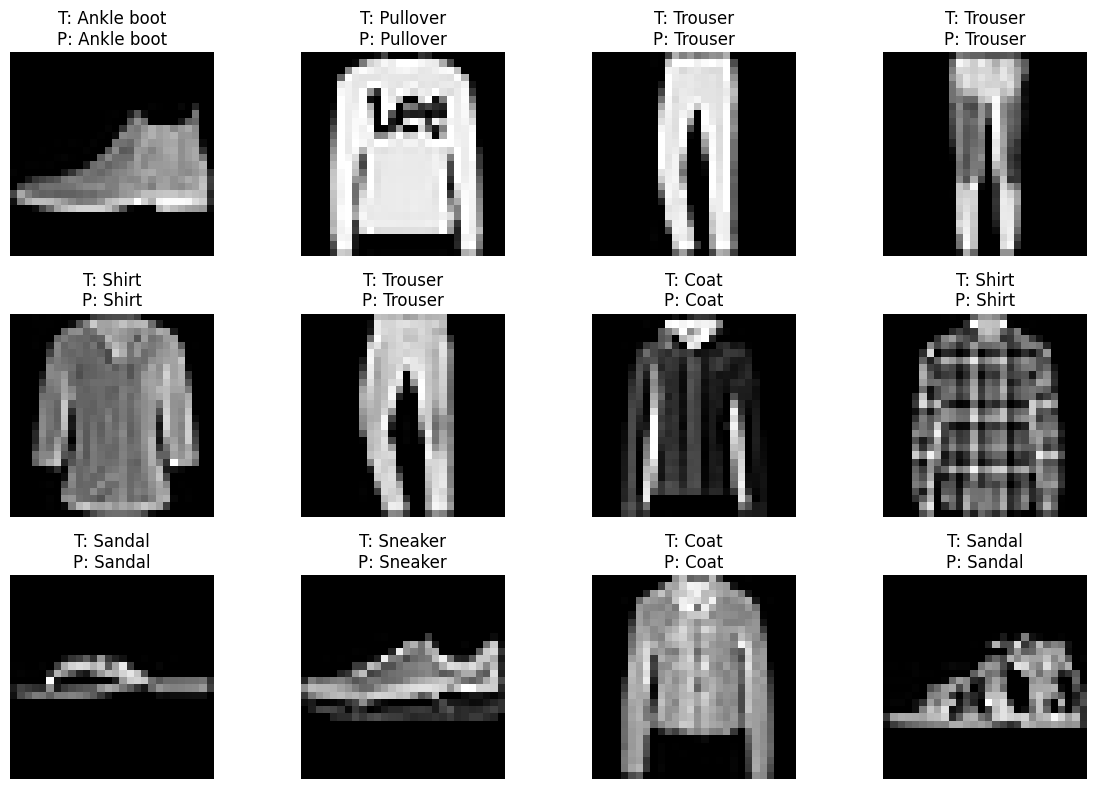

In [87]:
num_images = 12

plt.figure(
    figsize=(12, 8)
)

for i in range(num_images):

    image, true_label = test_dataset[i]

    image_input = image.unsqueeze(0).to(device)

    with torch.no_grad():

        output = loaded_model(
            image_input
        )

        predicted_label = torch.argmax(
            output,
            dim=1
        ).item()

    plt.subplot(
        3,
        4,
        i + 1
    )

    plt.imshow(
        image.squeeze(),
        cmap="gray"
    )

    plt.title(
        f"T: {classes[true_label]}\n"
        f"P: {classes[predicted_label]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [88]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=classes
    )
)

              precision    recall  f1-score   support

 T-shirt/top       0.85      0.86      0.86      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.84      0.91      0.87      1000
       Dress       0.91      0.93      0.92      1000
        Coat       0.89      0.85      0.87      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.79      0.72      0.75      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.97      0.96      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



In [89]:
print("Model architecture:")
print(loaded_model)

print("\nModel file:")
print(model_path)

print(
    "\nModel exists:",
    os.path.exists(model_path)
)

Model architecture:
CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)

Model file:
CNN-Image-Classification/model/220150.pth

Model exists: True


In [90]:
print("=" * 50)
print("CNN IMAGE CLASSIFICATION - FINAL RESULT")
print("=" * 50)

print(
    f"Training Accuracy: "
    f"{train_accuracies[-1]:.2f}%"
)

print(
    f"Validation Accuracy: "
    f"{val_accuracies[-1]:.2f}%"
)

print(
    f"Test Accuracy: "
    f"{test_accuracy:.2f}%"
)

print("=" * 50)

CNN IMAGE CLASSIFICATION - FINAL RESULT
Training Accuracy: 96.61%
Validation Accuracy: 92.47%
Test Accuracy: 91.62%


In [91]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles and folders:")
print(os.listdir("/content"))

Current directory:
/content

Files and folders:
['.config', 'CNN-Image-Classification', 'data', 'sample_data']


In [92]:


!git clone https://github.com/tirtho2002/CNN-Image-Classification.git

fatal: destination path 'CNN-Image-Classification' already exists and is not an empty directory.


In [93]:
import os

repo_path = "/content/CNN-Image-Classification"

print("GitHub repository contains:")
print(os.listdir(repo_path))

GitHub repository contains:
['dataset', 'images', 'model', 'README.md', 'custom_images', '.git']


In [94]:
import os

custom_dir = "/content/CNN-Image-Classification/custom_images"

print("Custom images:")

image_files = [
    file
    for file in os.listdir(custom_dir)
    if file.lower().endswith(
        (".jpg", ".jpeg", ".png", ".bmp")
    )
]

print("Number of images:", len(image_files))

for file in image_files:
    print(file)

Custom images:
Number of images: 10
sandal.jpeg
bag2.jpeg
sneaker.jpeg
tshirt2.jpeg
sandal2.jpeg
trouser2.jpeg
tshirt.jpeg
trouser.jpeg
bag.jpg
sneaker2.jpeg


In [95]:
!git -C /content/CNN-Image-Classification pull

Already up to date.


In [96]:
import os

print(os.path.exists("/content/model.pth"))

False


In [97]:
!rm -rf /content/CNN-Image-Classification

In [98]:
!git clone https://github.com/tirtho2002/CNN-Image-Classification.git

Cloning into 'CNN-Image-Classification'...
remote: Enumerating objects: 128, done.
remote: Counting objects: 100% (128/128), done.
remote: Compressing objects: 100% (117/117), done.
remote: Total 128 (delta 33), reused 34 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (128/128), 5.05 MiB | 18.66 MiB/s, done.
Resolving deltas: 100% (33/33), done.


In [99]:
import os

model_dir = "/content/CNN-Image-Classification/model"

print("Model files:")
print(os.listdir(model_dir))

Model files:
['model.pth']


In [100]:
import os

custom_dir = "/content/CNN-Image-Classification/custom_images"

image_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp"
)

image_files = [
    file
    for file in os.listdir(custom_dir)
    if file.lower().endswith(image_extensions)
]

image_files = sorted(image_files)

print("Number of custom images:", len(image_files))
print("Images:")

for file in image_files:
    print(file)

Number of custom images: 10
Images:
bag.jpg
bag2.jpeg
sandal.jpeg
sandal2.jpeg
sneaker.jpeg
sneaker2.jpeg
trouser.jpeg
trouser2.jpeg
tshirt.jpeg
tshirt2.jpeg


In [101]:
custom_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,),
        (0.5,)
    )
])

In [102]:
model_path = "CNN-Image-Classification/model/model.pth"

In [103]:
model_path = "/content/CNN-Image-Classification/model/model.pth"

loaded_model = CNN().to(device)

loaded_model.load_state_dict(
    torch.load(
        model_path,
        map_location=device
    )
)

loaded_model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [104]:
from PIL import Image
import torch

def predict_custom_image(image_path):

    image = Image.open(image_path)

    image_tensor = custom_transform(image)

    image_tensor = image_tensor.unsqueeze(0)
    image_tensor = image_tensor.to(device)

    with torch.no_grad():

        output = loaded_model(image_tensor)

        probabilities = torch.softmax(
            output,
            dim=1
        )

        predicted_class = torch.argmax(
            probabilities,
            dim=1
        ).item()

        confidence = (
            probabilities[0, predicted_class].item()
            * 100
        )

    return classes[predicted_class], confidence

In [105]:
results = []

for filename in image_files:

    image_path = os.path.join(
        custom_dir,
        filename
    )

    predicted_class, confidence = (
        predict_custom_image(image_path)
    )

    results.append({
        "filename": filename,
        "prediction": predicted_class,
        "confidence": confidence
    })

    print(
        f"{filename} → "
        f"{predicted_class} "
        f"({confidence:.2f}%)"
    )

bag.jpg → Bag (46.70%)
bag2.jpeg → Bag (99.98%)
sandal.jpeg → Bag (59.03%)
sandal2.jpeg → Bag (66.67%)
sneaker.jpeg → Bag (35.31%)
sneaker2.jpeg → Bag (97.67%)
trouser.jpeg → Shirt (27.89%)
trouser2.jpeg → Bag (83.65%)
tshirt.jpeg → Bag (79.05%)
tshirt2.jpeg → Bag (81.25%)


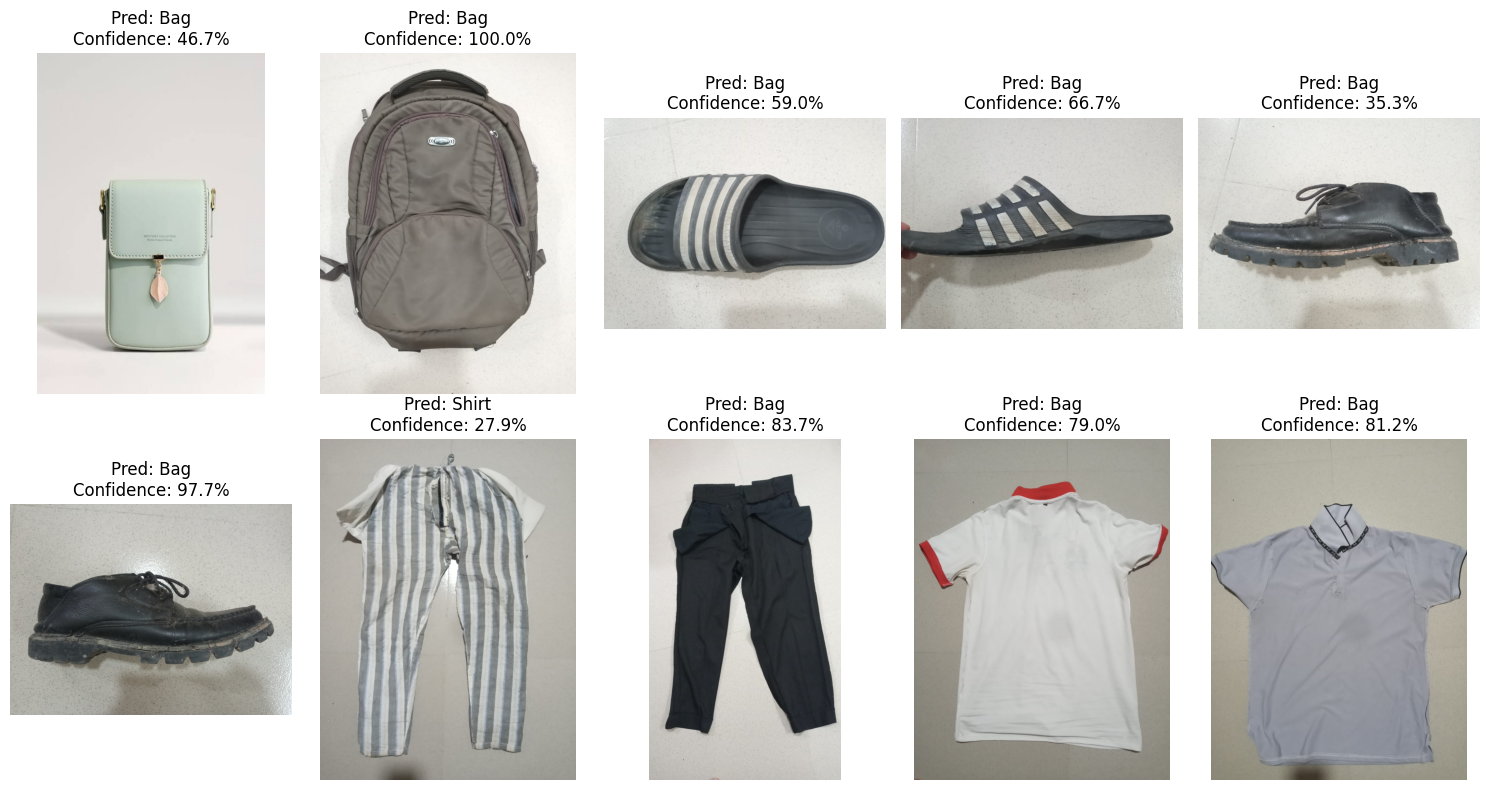

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

for i, result in enumerate(results):

    image_path = os.path.join(
        custom_dir,
        result["filename"]
    )

    image = Image.open(image_path)

    plt.subplot(2, 5, i + 1)

    plt.imshow(image)

    plt.title(
        f"Pred: {result['prediction']}\n"
        f"Confidence: {result['confidence']:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()